<a href="https://colab.research.google.com/github/SofiiaBobr/goit_machine_learning/blob/main/GaussianMixture_WorldHappiness_Homework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання. Gaussian Mixture для World Happiness Report

У роботі:
- завантажуються та досліджуються дані;
- аналізуються розподіли та кореляції;
- виконується стандартизація;
- будується модель Gaussian Mixture;
- аналізується вплив різних наборів ознак.


In [1]:
# Встановлення бібліотек (Colab)
!pip -q install plotly==5.20.0
!pip -q install "jupyterlab>=3" "ipywidgets>=7.6"

!wget -O WorldHappinessReport.zip https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
!unzip -o WorldHappinessReport.zip


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.7/15.7 MB 50.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 101.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 913.3/913.3 kB 55.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.5/77.5 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.8/59.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 134.0 MB/s eta 0:00:00
--2026-07-20 10:22:39--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/blob/main/WorldHappinessReport.zip?raw=true
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/refs/heads/main/WorldHappinessReport.zip [following]
--2026-07-20 10:22:40--  https://github.com/goitacademy/NUMERICAL-PROGRAMMING-IN-PYTHON/raw/re

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.preprocessing import MinMaxScaler,StandardScaler,Normalizer
from sklearn.mixture import GaussianMixture

df=pd.read_csv("2017.csv")
display(df.head())
df.info()
display(df.describe())


,Country,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
0,Norway,1,7.537,7.594445,7.479556,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027
1,Denmark,2,7.522,7.581728,7.462272,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707
2,Iceland,3,7.504,7.622030,7.385970,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715
3,Switzerland,4,7.494,7.561772,7.426227,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716
4,Finland,5,7.469,7.527542,7.410458,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 155 entries, 0 to 154
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Country                        155 non-null    object 
 1   Happiness.Rank                 155 non-null    int64  
 2   Happiness.Score                155 non-null    float64
 3   Whisker.high                   155 non-null    float64
 4   Whisker.low                    155 non-null    float64
 5   Economy..GDP.per.Capita.       155 non-null    float64
 6   Family                         155 non-null    float64
 7   Health..Life.Expectancy.       155 non-null    float64
 8   Freedom                        155 non-null    float64
 9   Generosity                     155 non-null    float64
 10  Trust..Government.Corruption.  155 non-null    float64
 11  Dystopia.Residual              155 non-null    float64
dtypes: float64(10), int64(1), object(1)
memory usage: 

,Happiness.Rank,Happiness.Score,Whisker.high,Whisker.low,Economy..GDP.per.Capita.,Family,Health..Life.Expectancy.,Freedom,Generosity,Trust..Government.Corruption.,Dystopia.Residual
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,78.000000,5.354019,5.452326,5.255713,0.984718,1.188898,0.551341,0.408786,0.246883,0.123120,1.850238
std,44.888751,1.131230,1.118542,1.145030,0.420793,0.287263,0.237073,0.149997,0.134780,0.101661,0.500028
min,1.000000,2.693000,2.864884,2.521116,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914
25%,39.500000,4.505500,4.608172,4.374955,0.663371,1.042635,0.369866,0.303677,0.154106,0.057271,1.591291
50%,78.000000,5.279000,5.370032,5.193152,1.064578,1.253918,0.606042,0.437454,0.231538,0.089848,1.832910
75%,116.500000,6.101500,6.194600,6.006527,1.318027,1.414316,0.723008,0.516561,0.323762,0.153296,2.144654
max,155.000000,7.537000,7.622030,7.479556,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485


## Розподіли числових ознак

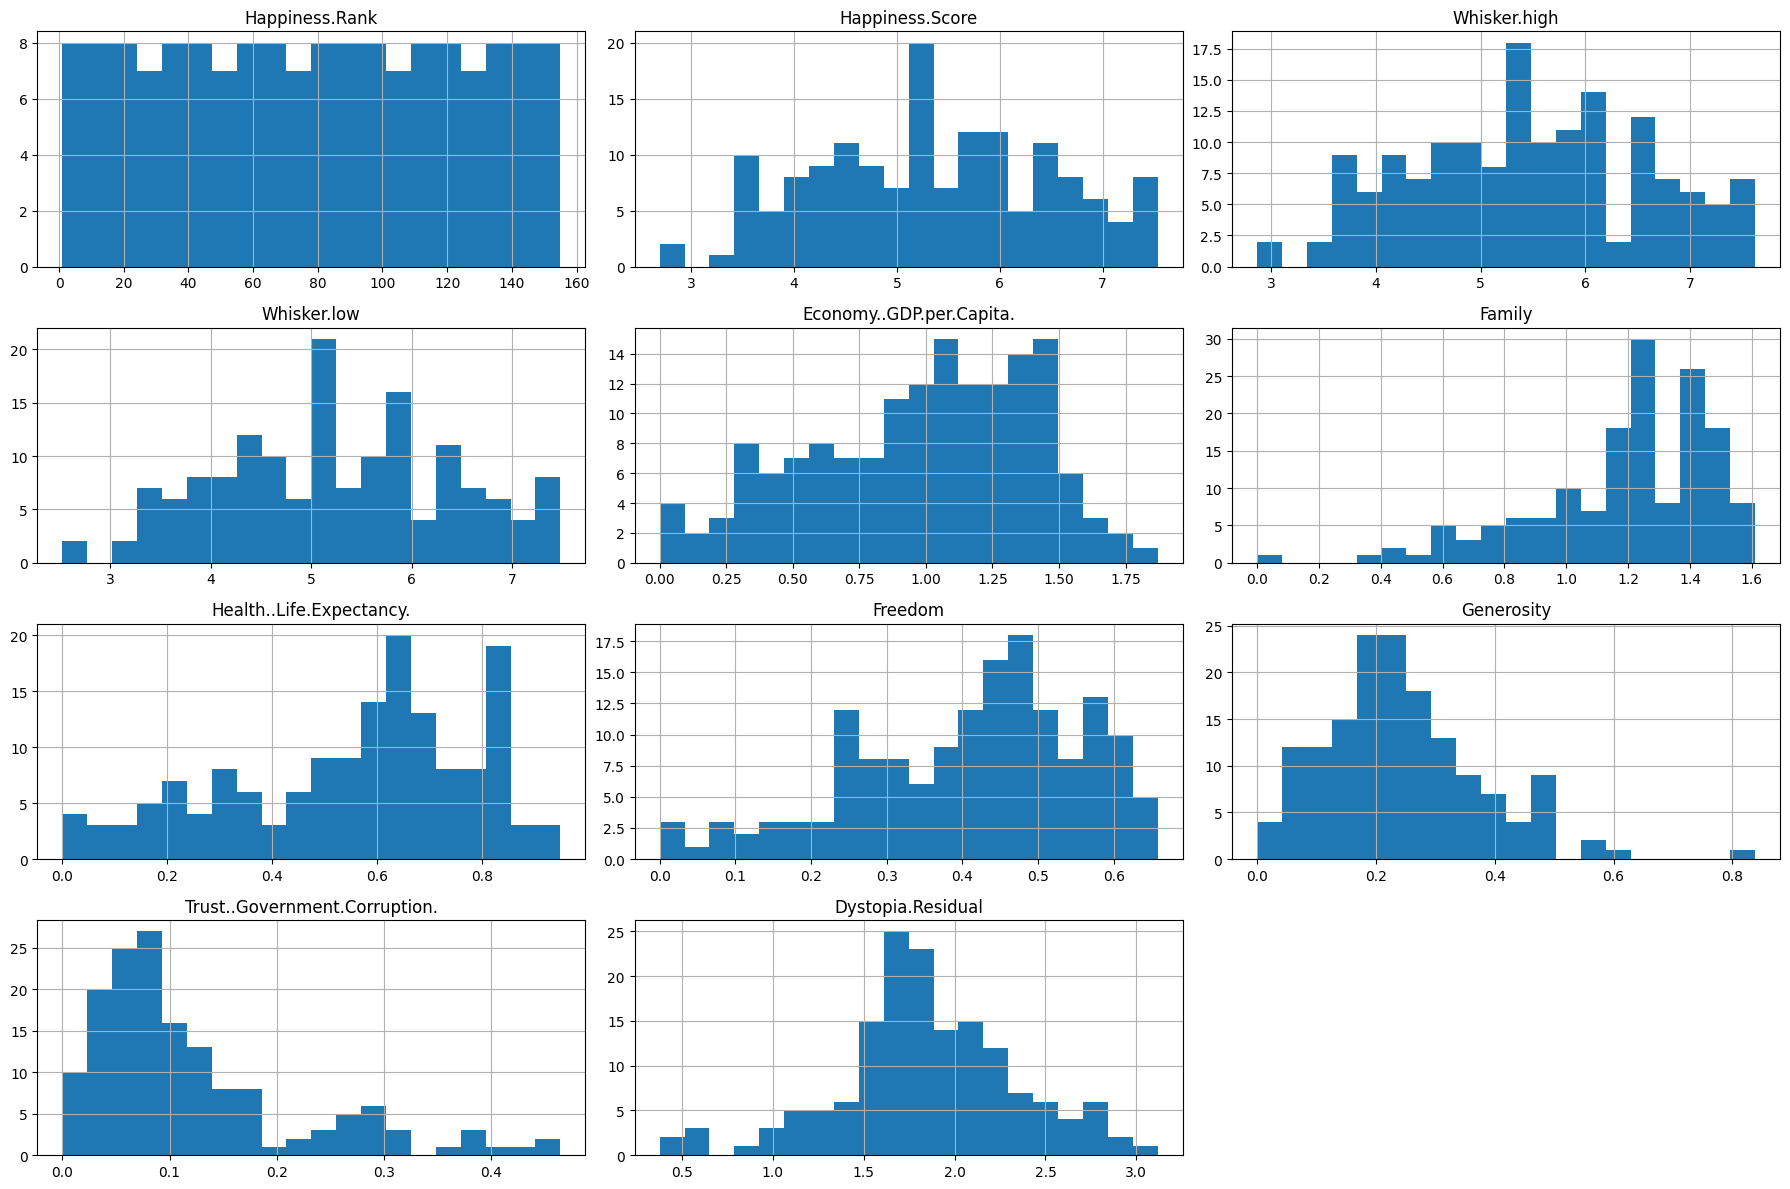

Більшість ознак не є ідеально нормально розподіленими, присутня асиметрія.


In [3]:
numeric=df.select_dtypes(include=np.number)
numeric.hist(figsize=(18,12),bins=20)
plt.tight_layout()
plt.show()

print("Більшість ознак не є ідеально нормально розподіленими, присутня асиметрія.")


## Кореляція

,Happiness.Score,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Freedom,Trust..Government.Corruption.,Generosity
Happiness.Score,1.000000,0.812469,0.781951,0.570137,0.429080,0.155256
Economy..GDP.per.Capita.,0.812469,1.000000,0.843077,0.369873,0.350944,-0.019011
Health..Life.Expectancy.,0.781951,0.843077,1.000000,0.349827,0.279752,0.063191
Freedom,0.570137,0.369873,0.349827,1.000000,0.499183,0.316083
Trust..Government.Corruption.,0.429080,0.350944,0.279752,0.499183,1.000000,0.294159
Generosity,0.155256,-0.019011,0.063191,0.316083,0.294159,1.000000


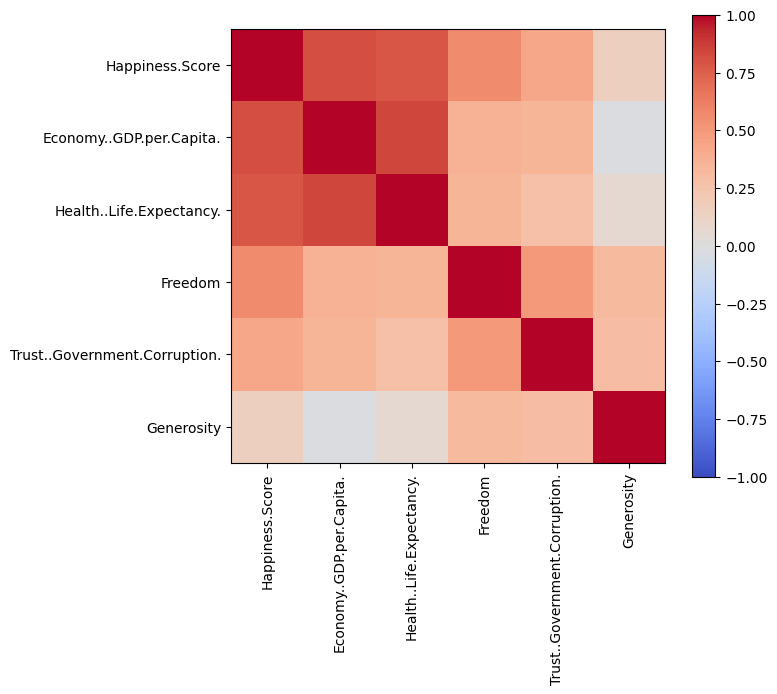

In [4]:
features=[
'Happiness.Score',
'Economy..GDP.per.Capita.',
'Health..Life.Expectancy.',
'Freedom',
'Trust..Government.Corruption.',
'Generosity'
]
corr=df[features].corr()
display(corr)

plt.figure(figsize=(7,6))
plt.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1)
plt.xticks(range(len(features)),features,rotation=90)
plt.yticks(range(len(features)),features)
plt.colorbar()
plt.show()


## Теплова карта щастя

In [5]:
fig=px.choropleth(
    df,
    locations="Country",
    color="Happiness.Score",
    locationmode="country names",
    title="Happiness Index 2017"
)
fig.show()


## Стандартизація

In [6]:
def data_scale(data, scaler_type='minmax'):
    if scaler_type=='minmax':
        scaler=MinMaxScaler()
    elif scaler_type=='std':
        scaler=StandardScaler()
    else:
        scaler=Normalizer()
    return scaler.fit_transform(data)

original=df[features]
scaled=data_scale(original,'std')
df_scaled=pd.DataFrame(scaled,columns=features)

display(original.describe())
display(df_scaled.describe())


,Happiness.Score,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Freedom,Trust..Government.Corruption.,Generosity
count,155.000000,155.000000,155.000000,155.000000,155.000000,155.000000
mean,5.354019,0.984718,0.551341,0.408786,0.123120,0.246883
std,1.131230,0.420793,0.237073,0.149997,0.101661,0.134780
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.505500,0.663371,0.369866,0.303677,0.057271,0.154106
50%,5.279000,1.064578,0.606042,0.437454,0.089848,0.231538
75%,6.101500,1.318027,0.723008,0.516561,0.153296,0.323762
max,7.537000,1.870766,0.949492,0.658249,0.464308,0.838075


,Happiness.Score,Economy..GDP.per.Capita.,Health..Life.Expectancy.,Freedom,Trust..Government.Corruption.,Generosity
count,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02,1.550000e+02
mean,-2.750488e-16,-2.750488e-16,-2.292073e-16,2.750488e-16,-9.168293e-17,1.203339e-16
std,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00,1.003241e+00
min,-2.359949e+00,-2.347736e+00,-2.333157e+00,-2.734123e+00,-1.215016e+00,-1.837684e+00
25%,-7.525169e-01,-7.661470e-01,-7.679616e-01,-7.030094e-01,-6.498388e-01,-6.905907e-01
50%,-6.653176e-02,1.903992e-01,2.314821e-01,1.917450e-01,-3.283529e-01,-1.142208e-01
75%,6.629099e-01,7.946657e-01,7.264573e-01,7.208448e-01,2.977939e-01,5.722497e-01
max,1.935996e+00,2.112488e+00,1.684893e+00,1.668506e+00,3.367022e+00,4.400552e+00


## Gaussian Mixture

In [7]:
gmm=GaussianMixture(n_components=4,random_state=42)
clusters=gmm.fit_predict(df_scaled)

df['Cluster']=clusters

display(df[['Country','Happiness.Score','Cluster']].head())


,Country,Happiness.Score,Cluster
0,Norway,7.537,0
1,Denmark,7.522,0
2,Iceland,7.504,0
3,Switzerland,7.494,0
4,Finland,7.469,0


## Карта кластерів

In [8]:
fig=px.choropleth(
    df,
    locations='Country',
    color='Cluster',
    locationmode='country names',
    title='Gaussian Mixture Clusters'
)
fig.show()


## Дослідження різних наборів ознак

In [9]:
feature_sets={
'Full':features,
'Economic':['Economy..GDP.per.Capita.','Health..Life.Expectancy.','Freedom'],
'Social':['Family','Generosity','Trust..Government.Corruption.']
}

for name,cols in feature_sets.items():
    data=data_scale(df[cols],'std')
    labels=GaussianMixture(n_components=4,random_state=42).fit_predict(data)
    print(name)
    print(pd.Series(labels).value_counts().sort_index())
    print()


Full
0    24
1    40
2    48
3    43
Name: count, dtype: int64

Economic
0    77
1    20
2    32
3    26
Name: count, dtype: int64

Social
0    26
1    15
2    75
3    39
Name: count, dtype: int64



# Висновки

- Виконано аналіз структури та статистик набору даних.
- Побудовано гістограми та кореляційну матрицю.
- Проведено стандартизацію ознак і порівняно статистики до та після масштабування.
- Побудовано модель Gaussian Mixture та отримано кластери країн.
- Побудовано карту світу із кластерами.
- Досліджено вплив різних наборів ознак на результат кластеризації.

**Висновок:** результат кластеризації загалом узгоджується з індексом щастя: країни з подібними економічними та соціальними показниками переважно потрапляють до одних і тих самих кластерів. Зміна набору ознак впливає на склад кластерів, що підтверджує важливість вибору релевантних характеристик.
